# Using biomed.sm.mv-te-84m Models Via SmallMoleculeMultiViewModel API

In [2]:
# Necessary Imports
from bmfm_sm.api.smmv_api import SmallMoleculeMultiViewModel, PredictionIterator
from bmfm_sm.core.data_modules.namespace import LateFusionStrategy
from bmfm_sm.api.dataset_registry import DatasetRegistry

#imports for new BiomedMultiViewEncoder class
from bmfm_sm.predictive.data_modules.image_finetune_dataset import ImageFinetuneDataPipeline
from bmfm_sm.predictive.data_modules.text_finetune_dataset import TextFinetuneDataPipeline
from bmfm_sm.predictive.data_modules.graph_finetune_dataset import Graph2dFinetuneDataPipeline

from dataclasses import asdict
from itertools import islice
import pandas as pd
import os
import torch
import torch.nn as nn

#imports for visualization
import numpy as np
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt
import seaborn as sns

/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/torch_geometric/typing.py:18: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: dlopen(/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/libpyg.so, 0x0006): tried: '/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/libpyg.so' (mach-o file, but is an incompatible architecture (have 'x86_64', need 'arm64e' or 'arm64')), '/System/Volumes/Preboot/Cryptexes/OS/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/libpyg.so' (no such file), '/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/libpyg.so' (mach-o file, but is an incompatible architecture (have 'x86_64', need 'arm64e' or 'arm64'))
  warnings.warn(f"An issue occurred

In [3]:
from torch.nn.functional import pad
from torch.nn.utils.rnn import pad_sequence

class BiomedMultiViewEncoder(nn.Module):
    def __init__(
        self
    ):
        super(BiomedMultiViewEncoder, self).__init__()
        # Initialize the pretrained model
        biomed_smmv_pretrained = SmallMoleculeMultiViewModel.from_pretrained(
            LateFusionStrategy.ATTENTIONAL,
            #model_path='../data_root/bmfm_model_dir/pretrained/MULTIVIEW_MODEL/biomed-smmv-with-coeff-agg.pth',
            inference_mode=False,
        )
        # Initialize the model subcomponents
        self.model_graph = biomed_smmv_pretrained.model_graph # output dim: 512
        self.model_image = biomed_smmv_pretrained.model_image # output dim: 512
        self.model_text = biomed_smmv_pretrained.model_text   # output dim: 768

    # Helper function for collating the individual processed graph samples:
    @staticmethod
    def collate_graph_data(graph_data_list):
        collated = {}
        collated["node_num"] = torch.cat([sample['node_num'] for sample in graph_data_list])
        collated["node_data"] = torch.cat([sample['node_data'] for sample in graph_data_list])
        collated["edge_num"] = torch.cat([sample['edge_num'] for sample in graph_data_list])
        collated["edge_data"] = torch.cat([sample['edge_data'] for sample in graph_data_list])
        collated["edge_index"] = torch.cat([sample['edge_index'] for sample in graph_data_list], dim=1)

        max_node_num = max(collated["node_num"])
        collated["lap_eigvec"] = torch.cat(
                [
                    pad(i, (0, max_node_num - i.size(1)), value=float("0"))
                    for i in [sample["lap_eigvec"] for sample in graph_data_list]
                ]
            )
        return collated

    def forward(self, smiles: list):
        tokenized_smiles_list = []
        attention_mask_list = []
        graph_data_list = []
        
        image_tensors = []
        graph_emb = []

        for sm in smiles:
            # Prepare image and text data in batch format
            img_data = ImageFinetuneDataPipeline.smiles_to_image_format(sm)
            image_tensors.append(img_data['img'].squeeze(0)) # Remove extra batch dimension if present

            txt_data = TextFinetuneDataPipeline.smiles_to_text_format(sm)
            tokenized_smiles_list.append(txt_data['smiles.tokenized'].squeeze(0))
            attention_mask_list.append(txt_data['attention_mask'].squeeze(0))

            # Run the graph model on individual smiles
            graph_data = Graph2dFinetuneDataPipeline.smiles_to_graph_format(sm)
            graph_data_list.append(graph_data)
            #graph_emb.append(self.model_graph(graph_data).squeeze(0))

        # Run the image and text models on the batched data
        image_batch = torch.stack(image_tensors, dim=0) #.to(device)
        tokenized_smiles_batch = pad_sequence(tokenized_smiles_list, batch_first=True) #.to(device)
        attention_mask_batch = pad_sequence(attention_mask_list, batch_first=True) #.to(device)
        graph_batch = BiomedMultiViewEncoder.collate_graph_data(graph_data_list)
        
        image_emb = self.model_image(image_batch)
        text_emb = self.model_text(tokenized_smiles_batch, attention_mask_batch)
        graph_emb = self.model_graph(graph_batch)

        return [graph_emb, image_emb, text_emb]

## Explore the data

Following are the datasets available for evaluation, finetuning and inference.

In [26]:
pd.DataFrame(DatasetRegistry.get_instance().get_collection('MoleculeNet'))

,dataset_name,num_tasks,task_type,description,preferred_metric,path,example,collection,num_classes
0,BACE,1,TaskType.CLASSIFICATION,MoleculeNet: Inhibition of human beta secretase 1,Metrics.ROCAUC,datasets/raw_data/MoleculeNet/bace.csv,"CC(C)CC1=CC=C(C=C1)C(C)C(=O)O,0",DatasetCollection.MOLECULENET,2.0
1,BBBP,1,TaskType.CLASSIFICATION,MoleculeNet: Blood brain barrier penetration,Metrics.ROCAUC,datasets/raw_data/MoleculeNet/bbbp.csv,"CC(C)CC1=CC=C(C=C1)C(C)C(=O)O,0",DatasetCollection.MOLECULENET,2.0
2,CLINTOX,2,TaskType.CLASSIFICATION,MoleculeNet: Toxicity data of FDA-approved dru...,Metrics.ROCAUC,datasets/raw_data/MoleculeNet/clintox.csv,"[N+](=O)([O-])[O-],1 0",DatasetCollection.MOLECULENET,2.0
3,ESOL,1,TaskType.REGRESSION,MoleculeNet: Water solubility data for organics,Metrics.RMSE,datasets/raw_data/MoleculeNet/esol.csv,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,DatasetCollection.MOLECULENET,NaN
4,FREESOLV,1,TaskType.REGRESSION,MoleculeNet: Hydration free energy,Metrics.RMSE,datasets/raw_data/MoleculeNet/freesolv.csv,"CN(C)C(=O)c1ccc(cc1)OC,-11.01",DatasetCollection.MOLECULENET,NaN
5,HIV,1,TaskType.CLASSIFICATION,MoleculeNet: Inhibition of HIV viral replication,Metrics.ROCAUC,datasets/raw_data/MoleculeNet/hiv.csv,"CC(C)CC1=CC=C(C=C1)C(C)C(=O)O,0",DatasetCollection.MOLECULENET,2.0
6,LIPOPHILICITY,1,TaskType.REGRESSION,MoleculeNet: Octonol/water distribution coefff...,Metrics.RMSE,datasets/raw_data/MoleculeNet/lipophilicity.csv,"Cn1c(CN2CCN(CC2)c3ccc(Cl)cc3)nc4ccccc14,3.54",DatasetCollection.MOLECULENET,NaN
7,MUV,17,TaskType.CLASSIFICATION,MoleculeNet: PubChem derived target-activity t...,Metrics.ROCAUC,datasets/raw_data/MoleculeNet/muv.csv,Cc1cccc(N2CCN(C(=O)C34CC5CC(CC(C5)C3)C4)CC2)c1...,DatasetCollection.MOLECULENET,2.0
8,PCBA,128,TaskType.CLASSIFICATION,MoleculeNet: PubChem derived target-activity (...,Metrics.ROCAUC,datasets/raw_data/MoleculeNet/pcba.csv,"CC(=O)N1CCC2(CC1)NC(=O)N(c1ccccc1)N2,0 0 -1 0 ...",DatasetCollection.MOLECULENET,2.0
9,QM7,1,TaskType.REGRESSION,MoleculeNet: Electronic properties derived fro...,Metrics.MAE,datasets/raw_data/MoleculeNet/qm7.csv,"C([H])([H])([H])[H],-417.96",DatasetCollection.MOLECULENET,NaN


Get more information about a particular dataset

In [27]:
dataset = DatasetRegistry.get_instance().get_dataset_info('TOX21')
pd.DataFrame([asdict(dataset)])

,dataset_name,num_tasks,task_type,description,preferred_metric,path,example,collection,num_classes
0,TOX21,12,TaskType.CLASSIFICATION,MoleculeNet: Toxicity against set of targets,Metrics.ROCAUC,datasets/raw_data/MoleculeNet/tox21.csv,"CCOc1ccc2nc(S(N)(=O)=O)sc2c1,0 0 1 -1 -1 0 0 1...",DatasetCollection.MOLECULENET,2


In [5]:
# REFACTORED CODE
os.environ['BMFM_HOME'] = '/Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/data_root/package_tiny'

def get_all_moleculenet_smiles(datasets=None):
    """
    Returns a dictionary where keys are dataset names (e.g., 'ESOL', 'LIPOPHILICITY') 
    and values are lists of SMILES strings extracted from the corresponding CSV files.
    """
    dataset_registry = DatasetRegistry()
    
    # If no specific datasets are provided, use all MoleculeNet datasets
    if datasets is None:
        moleculenet_datasets = dataset_registry.get_collection('MoleculeNet')
        dataset_names = [dataset_info.dataset_name for dataset_info in moleculenet_datasets]
    else:
        dataset_names = datasets
        
    smiles_dict = {}
    for dataset_name in dataset_names:
        try:
            # Build file path using lower-case version of the dataset name
            csv_filename = f"{dataset_name.lower()}.csv"
            csv_path = f"/Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/data_root/datasets/raw_data/MoleculeNet/{csv_filename}"
            df = pd.read_csv(csv_path)
            
            # Assuming the second column holds the SMILES strings
            smiles_col = df.columns[1]
            # Assign the list directly (if you prefer a flat list) 
            smiles_dict[dataset_name] = df[smiles_col].tolist()
            # If you want to keep the append style (resulting in a nested list), you can do:
            # smiles_dict[dataset_name].append(df[smiles_col].tolist())
            # and then later flatten it.
            
            print(f"{dataset_name}: {len(smiles_dict[dataset_name])} SMILES found.")
            
        except Exception as e:
            print(f"Error processing dataset {dataset_name}: {str(e)}")
            continue

    return smiles_dict

# Retrieve SMILES for specific datasets (e.g., ESOL and LIPOPHILICITY)
datasets_to_process = ['ESOL', 'LIPOPHILICITY']
smiles_dict = get_all_moleculenet_smiles(datasets=datasets_to_process)

# Initialize the encoder
encoder = BiomedMultiViewEncoder()

# Define batch size for processing
batch_size = 10

# Process each dataset separately to generate and save embeddings
for dataset_name, smiles_list in smiles_dict.items():
    # If you used append() and the list is nested, flatten it:
    if smiles_list and isinstance(smiles_list[0], list):
        smiles_list = smiles_list[0]
    
    print(f"\nProcessing dataset: {dataset_name} with {len(smiles_list)} SMILES")
    
    graph_batches = []
    image_batches = []
    text_batches = []
    
    # Process in batches
    for i in range(0, len(smiles_list), batch_size):
        batch_smiles = smiles_list[i:i+batch_size]
        try:
            outputs = encoder(batch_smiles)
            graph_batches.append(outputs[0].detach().cpu().numpy())
            image_batches.append(outputs[1].detach().cpu().numpy())
            text_batches.append(outputs[2].detach().cpu().numpy())
            
            print(f"  Processed batch {i // batch_size + 1} of {((len(smiles_list)-1)//batch_size)+1}")
        except Exception as e:
            print(f"Error encoding batch starting at index {i} in {dataset_name}: {e}")
    
    # Concatenate embeddings for each modality if available
    if graph_batches:
        graph_embeddings = np.concatenate(graph_batches, axis=0)
        image_embeddings = np.concatenate(image_batches, axis=0)
        text_embeddings = np.concatenate(text_batches, axis=0)
        
        # Save embeddings to separate files for each dataset
        np.save(f'graph_embeddings_{dataset_name.lower()}.npy', graph_embeddings)
        np.save(f'image_embeddings_{dataset_name.lower()}.npy', image_embeddings)
        np.save(f'text_embeddings_{dataset_name.lower()}.npy', text_embeddings)
        
        print(f"Embeddings for {dataset_name} saved successfully.")
    else:
        print(f"No embeddings produced for dataset {dataset_name}.")


ESOL: 1128 SMILES found.
LIPOPHILICITY: 4200 SMILES found.


/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
2025-03-01 20:25:19,777 - root - INFO - MacBook-Pro-368.local:8575305792:0:0 - Using coeff_mlp architecture for aggregator
2025-03-01 20:25:19,778 - root - INFO - MacBook-Pro-368.local:8575305792:0:0 - dim_list [512, 512, 768] for aggregator
2025-03-01 20:25:19,785 - root - INFO - MacBook-Pro-368.local:8575305792:0:0 - Loading checkpoint from default path


Processing dataset: ESOL with 1128 SMILES


/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/fast_transformers/feature_maps/fourier_features.py:37: UserWarning: torch.qr is deprecated in favor of torch.linalg.qr and will be removed in a future PyTorch release.
The boolean parameter 'some' has been replaced with a string parameter 'mode'.
Q, R = torch.qr(A, some)
should be replaced with
Q, R = torch.linalg.qr(A, 'reduced' if some else 'complete') (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2432.)
  Q, _ = torch.qr(block)


  Processed batch 1 of 113
  Processed batch 2 of 113
  Processed batch 3 of 113
  Processed batch 4 of 113
  Processed batch 5 of 113
  Processed batch 6 of 113
  Processed batch 7 of 113
  Processed batch 8 of 113
  Processed batch 9 of 113
  Processed batch 10 of 113
  Processed batch 11 of 113
  Processed batch 12 of 113
  Processed batch 13 of 113
  Processed batch 14 of 113
  Processed batch 15 of 113
  Processed batch 16 of 113
  Processed batch 17 of 113
  Processed batch 18 of 113
  Processed batch 19 of 113
  Processed batch 20 of 113
  Processed batch 21 of 113
  Processed batch 22 of 113
  Processed batch 23 of 113
  Processed batch 24 of 113
  Processed batch 25 of 113
  Processed batch 26 of 113
  Processed batch 27 of 113
  Processed batch 28 of 113
  Processed batch 29 of 113
  Processed batch 30 of 113
  Processed batch 31 of 113
  Processed batch 32 of 113
  Processed batch 33 of 113
  Processed batch 34 of 113
  Processed batch 35 of 113
  Processed batch 36 of 113
 

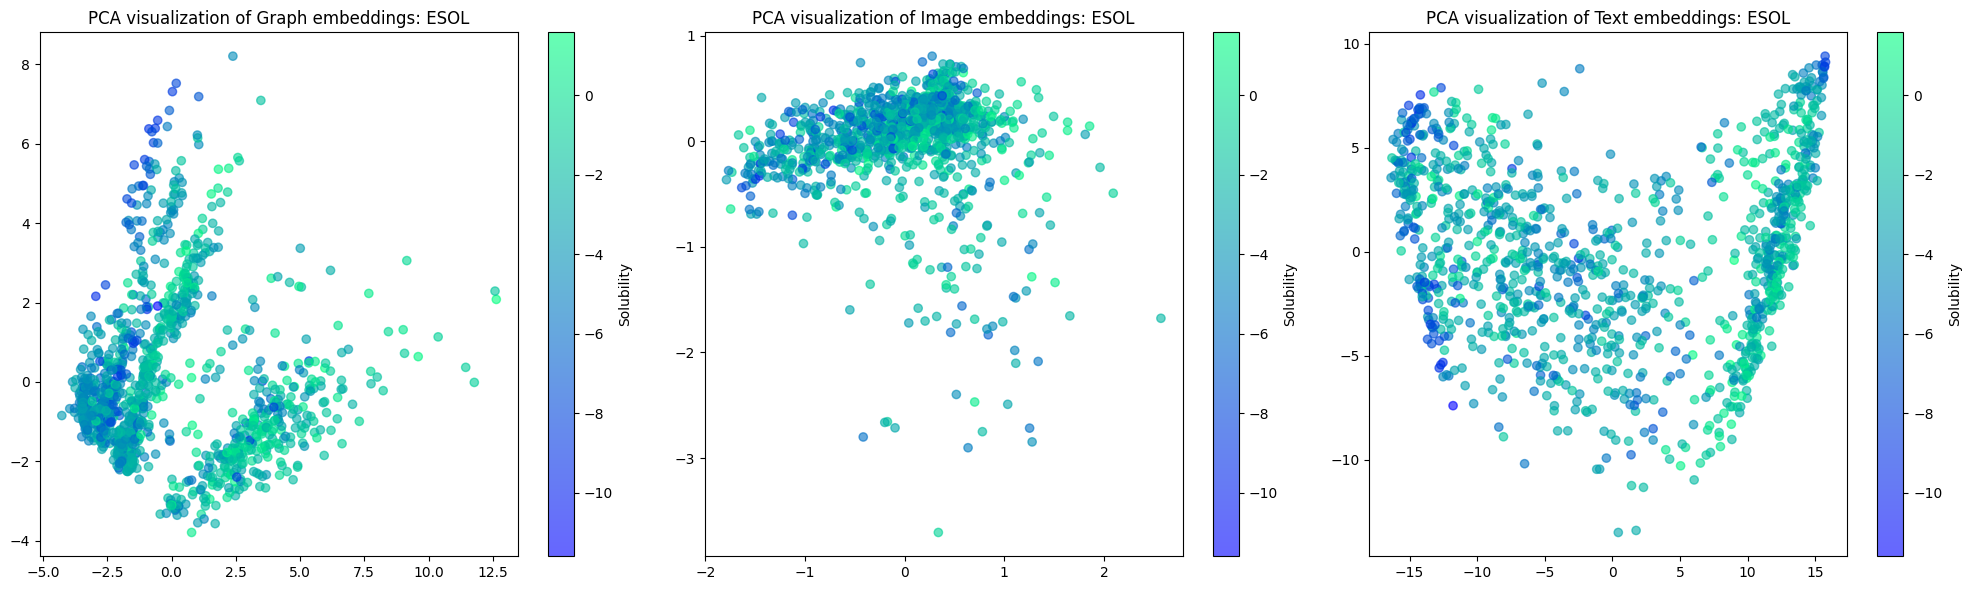

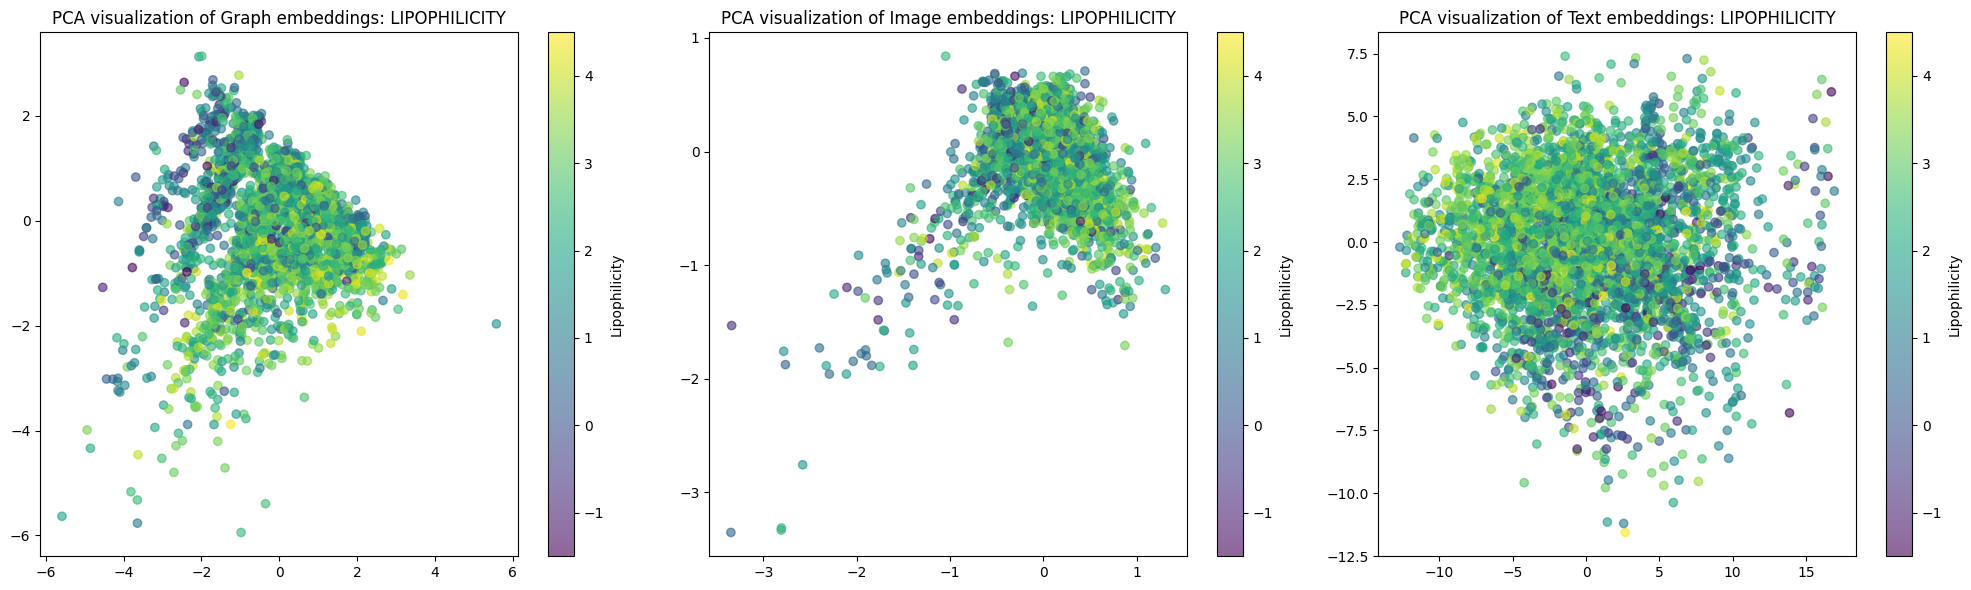

/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_j

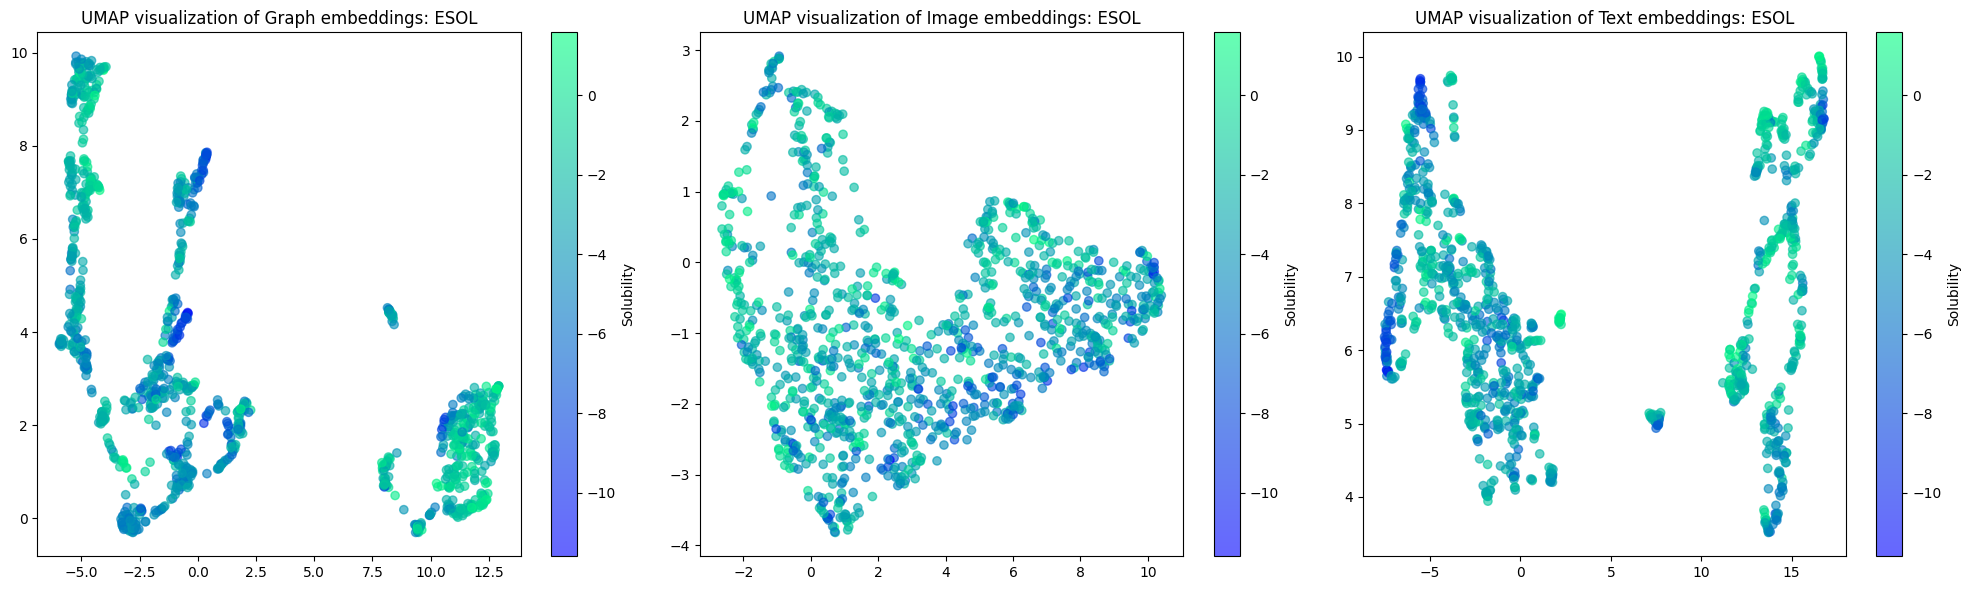

/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_j

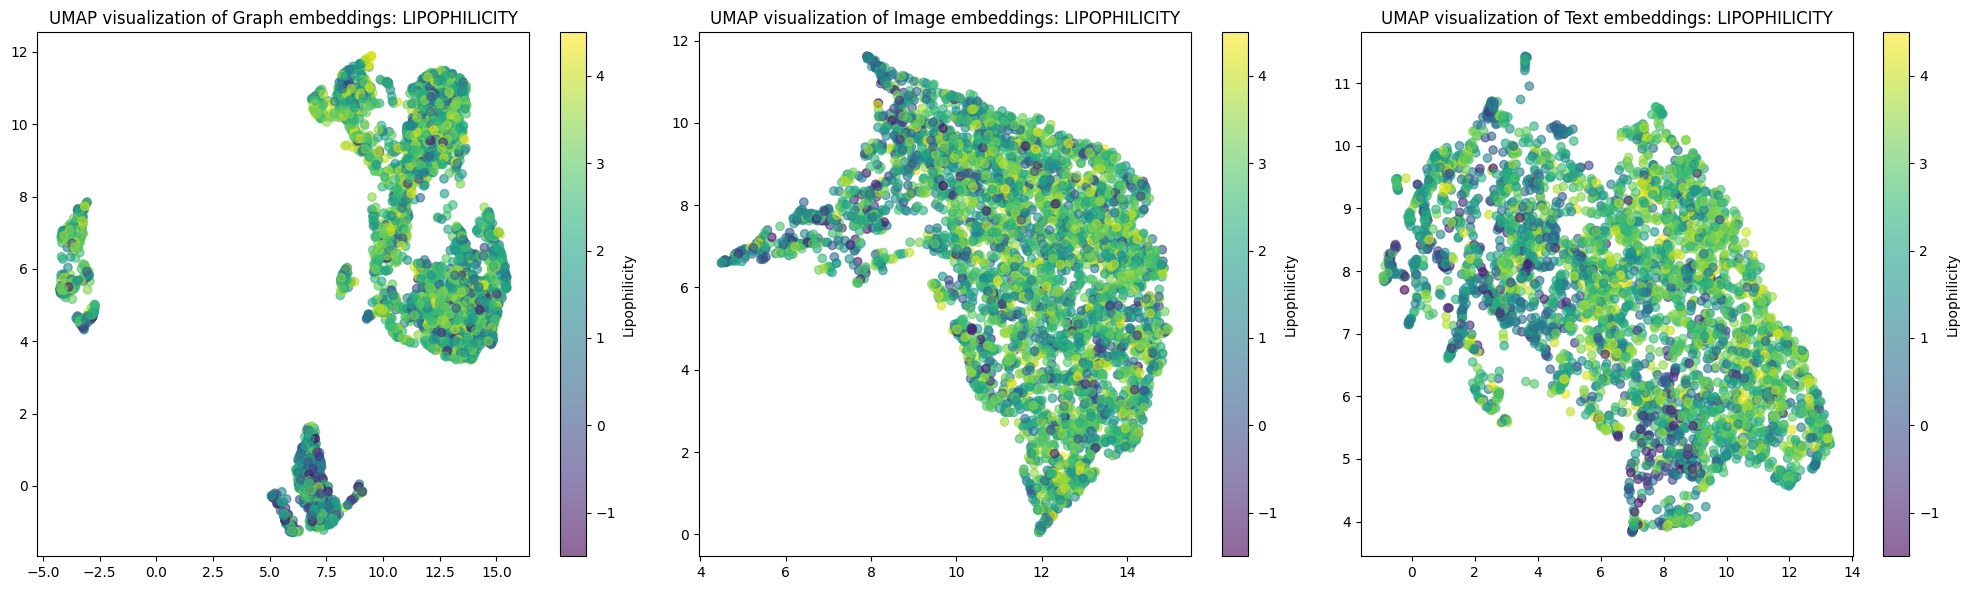

In [6]:
#REFACTORED CODE

def visualize_embeddings_separately(dataset_names, method='pca', cmap='viridis', colorbar_label='Label'):
    """
    Visualize the graph, image, and text embeddings using PCA or UMAP,
    and color the points by the provided label values using a sequential colormap.

    Parameters:
        graph_embs (ndarray): Graph modality embeddings.
        image_embs (ndarray): Image modality embeddings.
        text_embs (ndarray): Text modality embeddings.
        labels (list or array): Numeric labels (e.g., floating numbers) corresponding to each data point.
        method (str): 'pca' or 'umap' to choose the dimensionality reduction method.
        cmap (str): Colormap to use for coloring the points.
        colorbar_label (str): Label for the colorbar.

    Returns:
        None
    """
    # Ensure labels are in a numpy array
    for dataset_name in dataset_names:
        df = pd.read_csv(f"/Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/data_root/datasets/raw_data/MoleculeNet/{dataset_name.lower()}.csv")
        labels_col = df.columns[2]
        smiles_dict[dataset_name + '_labels'] = df[labels_col].tolist()
        labels = smiles_dict[dataset_name + '_labels']

        graph_embs = np.load(f"/Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/notebooks/graph_embeddings_{dataset_name.lower()}.npy")
        image_embs = np.load(f'/Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/notebooks/image_embeddings_{dataset_name.lower()}.npy')
        text_embs = np.load(f'/Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/notebooks/text_embeddings_{dataset_name.lower()}.npy')  
    
        def reduce_embeddings(embs):
            if method.lower() == 'pca':
                reducer = PCA(n_components=2)
            elif method.lower() == 'umap':
                reducer = umap.UMAP(n_components=2, random_state=42)
            else:
                raise ValueError(f"Unknown reduction method: {method}")
            return reducer.fit_transform(embs)
        
        # Create a figure with 3 subplots for each modality
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
        
        # Visualize Graph embeddings
        reduced_graph = reduce_embeddings(graph_embs)
        scatter1 = ax1.scatter(reduced_graph[:, 0], reduced_graph[:, 1],
                            c=labels, cmap=cmap, alpha=0.6)
        ax1.set_title(f'{method.upper()} visualization of Graph embeddings: {dataset_name}')
        fig.colorbar(scatter1, ax=ax1, label=colorbar_label)
        
        # Visualize Image embeddings
        reduced_image = reduce_embeddings(image_embs)
        scatter2 = ax2.scatter(reduced_image[:, 0], reduced_image[:, 1],
                            c=labels, cmap=cmap, alpha=0.6)
        ax2.set_title(f'{method.upper()} visualization of Image embeddings: {dataset_name}')
        fig.colorbar(scatter2, ax=ax2, label=colorbar_label)
        
        # Visualize Text embeddings
        reduced_text = reduce_embeddings(text_embs)
        scatter3 = ax3.scatter(reduced_text[:, 0], reduced_text[:, 1],
                            c=labels, cmap=cmap, alpha=0.6)
        ax3.set_title(f'{method.upper()} visualization of Text embeddings: {dataset_name}')
        fig.colorbar(scatter3, ax=ax3, label=colorbar_label)
        
        plt.tight_layout()
        plt.show()


esol = ['ESOL']
lipo = ['LIPOPHILICITY']

visualize_embeddings_separately(esol, method='pca', cmap='winter', colorbar_label='Solubility')
visualize_embeddings_separately(lipo, method='pca', cmap='viridis', colorbar_label='Lipophilicity')
visualize_embeddings_separately(esol, method='umap', cmap='winter', colorbar_label='Solubility')
visualize_embeddings_separately(lipo, method='umap', cmap='viridis', colorbar_label='Lipophilicity')

## Using Models from HuggingFace

We have made pretrained and finetuned models available in [HuggingFace](https://huggingface.co/ibm/biomed.sm.mv-te-84m)

### Loading Pretrained Model from HuggingFace

Load a pretrained model from Huggingface by setting `model_path` to a Huggingface repo, and setting the `huggingface` argument to `True`

In [7]:
model = SmallMoleculeMultiViewModel.from_pretrained(LateFusionStrategy.ATTENTIONAL,
                                                    model_path='ibm/biomed.sm.mv-te-84m',
                                                    huggingface=True)

2025-03-01 20:44:26,510 - root - INFO - MacBook-Pro-368.local:8575305792:0:0 - Loading checkpoint via HuggingFace Hub from provided path ibm/biomed.sm.mv-te-84m
/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
2025-03-01 20:44:27,447 - root - INFO - MacBook-Pro-368.local:8575305792:0:0 - Using coeff_mlp architecture for aggregator
2025-03-01 20:44:27,448 - root - INFO - MacBook-Pro-368.local:8575305792:

### Get Embeddings from a Pretrained Model

In [8]:
example_smiles = "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O"
example_emb = SmallMoleculeMultiViewModel.get_embeddings(
    smiles=example_smiles,
    model_path="ibm/biomed.sm.mv-te-84m",
    huggingface=True,
)
print(example_emb.shape)

2025-03-01 20:44:30,650 - root - INFO - MacBook-Pro-368.local:8575305792:0:0 - Loading checkpoint via HuggingFace Hub from provided path ibm/biomed.sm.mv-te-84m
2025-03-01 20:44:31,553 - root - INFO - MacBook-Pro-368.local:8575305792:0:0 - Using coeff_mlp architecture for aggregator
2025-03-01 20:44:31,554 - root - INFO - MacBook-Pro-368.local:8575305792:0:0 - dim_list [512, 512, 768] for aggregator
2025-03-01 20:44:33,256 - root - INFO - MacBook-Pro-368.local:8575305792:0:0 - in train False setting deterministic_eval = True


torch.Size([512])


### Load Finetuned Model from HuggingFace

In [9]:
dataset_registry = DatasetRegistry()
ds = dataset_registry.get_dataset_info('BACE')

In [10]:
finetuned_model_ds = SmallMoleculeMultiViewModel.from_finetuned(
    ds,
    model_path="ibm/biomed.sm.mv-te-84m-MoleculeNet-ligand_scaffold-BACE-101",
    inference_mode=True,
    huggingface=True
)

2025-03-01 20:44:36,088 - root - INFO - MacBook-Pro-368.local:8575305792:0:0 - Loading checkpoint via HuggingFace Hub from provided path ibm/biomed.sm.mv-te-84m-MoleculeNet-ligand_scaffold-BACE-101
2025-03-01 20:44:36,926 - root - INFO - MacBook-Pro-368.local:8575305792:0:0 - Using coeff_mlp architecture for aggregator
2025-03-01 20:44:36,927 - root - INFO - MacBook-Pro-368.local:8575305792:0:0 - dim_list [512, 512, 768] for aggregator
2025-03-01 20:44:37,206 - root - INFO - MacBook-Pro-368.local:8575305792:0:0 - in train False setting deterministic_eval = True


### Get Predictions from Finetuned Model

In [11]:
# Get predictions
prediction = SmallMoleculeMultiViewModel.get_predictions(
    example_smiles, ds, finetuned_model=finetuned_model_ds
)
print(prediction)

tensor(0, dtype=torch.int32)


## Using Local Data

You can also download the checkpoints and data to your system and use the API. Follow procedure in the README for setting up the data. Make sure that `BMFM_HOME` environment variable is pointing to the data_root.

In [12]:
os.environ['BMFM_HOME'] = "/Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/data_root/package_tiny" 
print(os.environ['BMFM_HOME'])

/Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/data_root/package_tiny


### Loading Pretrained Model (Local)

Load our provided pretrained checkpoint, which uses a Attentional Late Fusion strategy (default). It loads the model in inference mode.

In [13]:
model_local = SmallMoleculeMultiViewModel.from_pretrained(LateFusionStrategy.ATTENTIONAL, inference_mode = True)

2025-03-01 20:44:42,889 - root - INFO - MacBook-Pro-368.local:8575305792:0:0 - Using coeff_mlp architecture for aggregator
2025-03-01 20:44:42,890 - root - INFO - MacBook-Pro-368.local:8575305792:0:0 - dim_list [512, 512, 768] for aggregator
2025-03-01 20:44:42,896 - root - INFO - MacBook-Pro-368.local:8575305792:0:0 - Loading checkpoint from default path /Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/data_root/package_tiny/bmfm_model_dir/pretrained/MULTIVIEW_MODEL/biomed-smmv-with-coeff-agg.pth
2025-03-01 20:44:42,982 - root - INFO - MacBook-Pro-368.local:8575305792:0:0 - Loading pretrain checkpoint for SmallMoleculeMultiView Model - <All keys matched successfully>
2025-03-01 20:44:42,987 - root - INFO - MacBook-Pro-368.local:8575305792:0:0 - in train False setting deterministic_eval = True


We can also load with a different fusion strategy - Note, aggregator will not be pretrained but BaseModel will be.

In [ ]:
model_local = SmallMoleculeMultiViewModel.from_pretrained(LateFusionStrategy.MOE_WEIGHTED_CONCAT_PROJECTED, inference_mode = True)

2025-01-30 15:37:25,362 - root - INFO - MacBook-Pro-231.local:7932416000:0:0 - Using moe_weighted_concat architecture for aggregator
2025-01-30 15:37:25,362 - root - INFO - MacBook-Pro-231.local:7932416000:0:0 - dim_list [512, 512, 768] for aggregator
2025-01-30 15:37:25,365 - root - INFO - MacBook-Pro-231.local:7932416000:0:0 - Loading checkpoint from default path /Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/data_root/package_tiny/bmfm_model_dir/pretrained/MULTIVIEW_MODEL/biomed-smmv-with-coeff-agg.pth
2025-01-30 15:37:25,439 - root - INFO - MacBook-Pro-231.local:7932416000:0:0 - Loading pretrain checkpoint for SmallMoleculeMultiView Model - _IncompatibleKeys(missing_keys=['aggregator.weighted_concat_network.gating_network.fc.weight', 'aggregator.weighted_concat_network.gating_network.fc.bias'], unexpected_keys=['aggregator.w_before_mean.0.weight', 'aggregator.w_before_mean.0.bias', 'aggregator.w_before_mean.2.weight', 'aggregator.down_project.weight'

We can also provide a `custom_model` path to load from a specific checkpoint

In [ ]:
ckpt_path = f"{os.environ['BMFM_HOME']}/bmfm_model_dir/pretrained/MULTIVIEW_MODEL/biomed-smmv-base.pth"
model_local = SmallMoleculeMultiViewModel.from_pretrained(LateFusionStrategy.CONCAT, 
                                     model_path=ckpt_path,
                                     inference_mode = True)

2025-01-30 15:37:28,404 - root - INFO - MacBook-Pro-231.local:7932416000:0:0 - Using concat architecture for aggregator
2025-01-30 15:37:28,405 - root - INFO - MacBook-Pro-231.local:7932416000:0:0 - dim_list [512, 512, 768] for aggregator
2025-01-30 15:37:28,405 - root - INFO - MacBook-Pro-231.local:7932416000:0:0 - Loading checkpoint from provided path /Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/data_root/package_tiny/bmfm_model_dir/pretrained/MULTIVIEW_MODEL/biomed-smmv-base.pth
2025-01-30 15:37:28,498 - root - INFO - MacBook-Pro-231.local:7932416000:0:0 - Loading pretrain checkpoint for SmallMoleculeMultiView Model - <All keys matched successfully>
2025-01-30 15:37:28,503 - root - INFO - MacBook-Pro-231.local:7932416000:0:0 - in train False setting deterministic_eval = True


We can set `model_path` to `False` if to load a non-pretrained model.

In [ ]:
model_local = SmallMoleculeMultiViewModel.from_pretrained(LateFusionStrategy.MOE_NOISED_WEIGHTED_CONCAT_BOTH_PROJECTED, 
                                     model_path=False,
                                     inference_mode = False)

2025-01-30 15:37:34,711 - root - INFO - MacBook-Pro-231.local:7932416000:0:0 - Using moe_noised_weighted_concat architecture for aggregator
2025-01-30 15:37:34,712 - root - INFO - MacBook-Pro-231.local:7932416000:0:0 - dim_list [512, 512, 768] for aggregator
2025-01-30 15:37:34,714 - root - INFO - MacBook-Pro-231.local:7932416000:0:0 - Not using checkpoint for model initialization


### Get Embeddings from a Pretrained Model (Local)

In [ ]:
example_smiles = "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O"
example_emb = SmallMoleculeMultiViewModel.get_embeddings(example_smiles)
example_emb.shape

2025-01-30 15:37:37,363 - root - INFO - MacBook-Pro-231.local:7932416000:0:0 - Using coeff_mlp architecture for aggregator
2025-01-30 15:37:37,364 - root - INFO - MacBook-Pro-231.local:7932416000:0:0 - dim_list [512, 512, 768] for aggregator
2025-01-30 15:37:37,371 - root - INFO - MacBook-Pro-231.local:7932416000:0:0 - Loading checkpoint from default path /Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/data_root/package_tiny/bmfm_model_dir/pretrained/MULTIVIEW_MODEL/biomed-smmv-with-coeff-agg.pth
2025-01-30 15:37:37,437 - root - INFO - MacBook-Pro-231.local:7932416000:0:0 - Loading pretrain checkpoint for SmallMoleculeMultiView Model - <All keys matched successfully>
2025-01-30 15:37:37,441 - root - INFO - MacBook-Pro-231.local:7932416000:0:0 - in train False setting deterministic_eval = True


torch.Size([512])

### Load Finetuned Model (Local)

Choose a supported dataset for which finetuned checkpoint is available

In [ ]:
#Example of a Classification Prediction
dataset_registry = DatasetRegistry()
bace_ds = dataset_registry.get_dataset_info('BACE')

In [ ]:
finetuned_model_bace_local = SmallMoleculeMultiViewModel.from_finetuned(bace_ds, inference_mode = True)

2025-01-30 15:37:43,603 - root - INFO - MacBook-Pro-231.local:7932416000:0:0 - Using coeff_mlp architecture for aggregator
2025-01-30 15:37:43,604 - root - INFO - MacBook-Pro-231.local:7932416000:0:0 - dim_list [512, 512, 768] for aggregator
2025-01-30 15:37:43,939 - root - INFO - MacBook-Pro-231.local:7932416000:0:0 - Loading finetune checkpoint for SmallMoleculeMultiView Model - <All keys matched successfully>
2025-01-30 15:37:44,097 - root - INFO - MacBook-Pro-231.local:7932416000:0:0 - Loading finetune checkpoint for Prediction Head: /Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/data_root/package_tiny/bmfm_model_dir/finetuned/MULTIVIEW_MODEL/MoleculeNet/ligand_scaffold/BACE/best-101.ckpt
2025-01-30 15:37:44,114 - root - INFO - MacBook-Pro-231.local:7932416000:0:0 - in train False setting deterministic_eval = True


In [ ]:
example_smiles = "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O"
bace_prediction = SmallMoleculeMultiViewModel.get_predictions(example_smiles, bace_ds, finetuned_model=finetuned_model_bace_local)
bace_prediction

tensor(0, dtype=torch.int32)

In [ ]:
#Example of a Regression Prediction
esol_ds = dataset_registry.get_dataset_info('ESOL')
finetuned_model_esol_local = SmallMoleculeMultiViewModel.from_finetuned(esol_ds, inference_mode = True)
esol_prediction = SmallMoleculeMultiViewModel.get_predictions(example_smiles, esol_ds, finetuned_model=finetuned_model_esol_local)
esol_prediction

2025-01-30 15:37:50,211 - root - INFO - MacBook-Pro-231.local:7932416000:0:0 - Using coeff_mlp architecture for aggregator
2025-01-30 15:37:50,211 - root - INFO - MacBook-Pro-231.local:7932416000:0:0 - dim_list [512, 512, 768] for aggregator
2025-01-30 15:37:50,378 - root - INFO - MacBook-Pro-231.local:7932416000:0:0 - Loading finetune checkpoint for SmallMoleculeMultiView Model - <All keys matched successfully>
2025-01-30 15:37:50,513 - root - INFO - MacBook-Pro-231.local:7932416000:0:0 - Loading finetune checkpoint for Prediction Head: /Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/data_root/package_tiny/bmfm_model_dir/finetuned/MULTIVIEW_MODEL/MoleculeNet/ligand_scaffold/ESOL/best-101.ckpt
2025-01-30 15:37:50,528 - root - INFO - MacBook-Pro-231.local:7932416000:0:0 - in train False setting deterministic_eval = True


tensor(-3.5531)